## 1. Descomprimir el Dataset

In [ ]:
import zipfile
import os

# Ruta de tu zip en Drive y dónde lo vamos a extraer en Colab
ruta_zip = '/content/drive/MyDrive/Dataset_Funkos.zip'
ruta_extraccion = '/content/dataset'

# Descomprimir
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(ruta_extraccion)

print("¡Dataset extraído correctamente!")

¡Dataset extraído correctamente!


## 2. Importación y División (Train, Val, Test)

In [ ]:
import tensorflow as tf

data_dir = '/content/dataset/Dataset_Funkos'

batch_size = 16 # Usamos 16 al tener 210 imágenes en total
img_height = 150
img_width = 150

print("--- Cargando datos de Entrenamiento (80%) ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

print("\n--- Cargando datos restantes (20%) ---")
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Obtenemos los nombres de las clases
class_names = train_ds.class_names
print(f"\nClases detectadas ({len(class_names)}): {class_names}")

# Dividir el 20% de validación por la mitad para sacar el conjunto de TEST
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print("\n--- Distribución final ---")
print(f"Lotes de Entrenamiento: {tf.data.experimental.cardinality(train_ds)}")
print(f"Lotes de Validación: {tf.data.experimental.cardinality(val_ds)}")
print(f"Lotes de Test: {tf.data.experimental.cardinality(test_ds)}")

--- Cargando datos de Entrenamiento (80%) ---
Found 210 files belonging to 7 classes.
Using 168 files for training.

--- Cargando datos restantes (20%) ---
Found 210 files belonging to 7 classes.
Using 42 files for validation.

Clases detectadas (7): ['Ace', 'Buzzlightyear', 'Inosuke', 'Kaido', 'Luffy', 'Luffy gear 4', 'Zoro']

--- Distribución final ---
Lotes de Entrenamiento: 11
Lotes de Validación: 2
Lotes de Test: 1


## 3. Visualización y Matriz de Datos

=== MATRIZ DE DATOS DE LA IMAGEN ===
Dimensiones (Alto, Ancho, Canales RGB): (150, 150, 3)
Muestra de los valores numéricos de los píxeles (esquina superior izquierda):
[[22.380001 25.380001 32.38    ]
 [22.439999 25.439999 32.44    ]
 [18.329996 23.329996 29.329996]]

=== VISUALIZACIÓN DE EJEMPLO ===


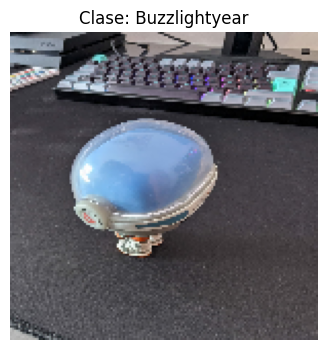

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extraemos un solo lote de imágenes
for image_batch, labels_batch in train_ds.take(1):
    imagen_ejemplo = image_batch[0].numpy()
    etiqueta_ejemplo = class_names[labels_batch[0]]

    # 1. Mostrar como matriz de datos
    print("=== MATRIZ DE DATOS DE LA IMAGEN ===")
    print(f"Dimensiones (Alto, Ancho, Canales RGB): {imagen_ejemplo.shape}")
    print("Muestra de los valores numéricos de los píxeles (esquina superior izquierda):")
    print(imagen_ejemplo[0][0:3]) # Muestra los primeros 3 píxeles

    # 2. Visualizar con matplotlib
    print("\n=== VISUALIZACIÓN DE EJEMPLO ===")
    plt.figure(figsize=(4, 4))
    plt.imshow(imagen_ejemplo.astype("uint8"))
    plt.title(f"Clase: {etiqueta_ejemplo}")
    plt.axis("off")
    plt.show()
    break # Solo queremos ver una

## 4. Preprocesamiento (Optimización)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Preprocesamiento completado: Datos cacheados y optimizados para el entrenamiento.")

Preprocesamiento completado: Datos cacheados y optimizados para el entrenamiento.


## 5. Diseño y Creación de la Red Neuronal (Modelo Base)

Para este primer acercamiento, hemos diseñado una Red Neuronal Convolucional (CNN) secuencial con la siguiente arquitectura capa a capa:

1. **Capa de Rescaling (Preprocesamiento):** Normaliza los valores de los píxeles dividiéndolos entre 255. Pasa la escala de colores de 0-255 a 0-1 para que la red procese los números más fácilmente.
2. **Capas Conv2D (Convolucionales):** Son las encargadas de extraer las características de las imágenes (bordes, colores, formas del Funko). Empezamos con 16 filtros, luego 32 y finalmente 64. Usamos la función de activación `relu`.
3. **Capas MaxPooling2D:** Reducen a la mitad las dimensiones espaciales después de cada convolución. Ayudan a que el modelo se quede con la información más importante y reducen el coste computacional.
4. **Capa Flatten:** Aplana la matriz de datos bidimensional (la imagen) convirtiéndola en un vector unidimensional (una fila de números) para poder conectarla con la red neuronal tradicional.
5. **Capa Dense (Oculta):** Una capa completamente conectada con 128 neuronas y activación `relu`, que procesa los patrones extraídos por las convoluciones para tomar decisiones.
6. **Capa Dense (Salida):** La última capa tiene tantas neuronas como clases tenemos en nuestro dataset (7). No le ponemos función de activación porque en la compilación usaremos `from_logits=True`.

## 6. Creación y Entrenamiento del Modelo

In [ ]:
num_classes = len(class_names)

# 1. Definición del modelo Secuencial
modelo_base = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes)
])

# 2. Compilación del modelo
modelo_base.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Mostramos el resumen de la arquitectura por pantalla
modelo_base.summary()

# 3. Entrenamiento del modelo
epocas = 10
print("\n--- INICIANDO ENTRENAMIENTO ---")
historia_base = modelo_base.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epocas
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,823 (10.22 MB)

 Trainable params: 2,678,823 (10.22 MB)

 Non-trainable params: 0 (0.00 B)


--- INICIANDO ENTRENAMIENTO ---
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 468ms/step - accuracy: 0.1905 - loss: 2.1277 - val_accuracy: 0.3077 - val_loss: 1.9159
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2560 - loss: 1.8727 - val_accuracy: 0.3077 - val_loss: 1.7550
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3571 - loss: 1.5611 - val_accuracy: 0.3846 - val_loss: 1.4253
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6071 - loss: 1.1036 - val_accuracy: 0.3462 - val_loss: 1.4246
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8095 - loss: 0.6579 - val_accuracy: 0.5000 - val_loss: 1.6788
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8095 - loss: 0.4788 - val_accuracy: 0.5385 - val_loss: 2.0056
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9167 - loss: 0.2832 - val_accuracy: 0.5000 - val_loss: 2.0072
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9583 - loss: 0.15

## 7. Visualización del Rendimiento (Modelo Base)

A continuación, extraemos las gráficas de evolución de la precisión (Accuracy) y la pérdida (Loss) durante las 10 épocas de entrenamiento.
Como se puede observar en las gráficas, nuestro modelo base sufre un claro caso de **sobreajuste (overfitting)**. Mientras que la precisión de entrenamiento sube rápidamente superando el 90%, la precisión de validación se estanca alrededor del 45-50%. La red ha memorizado las imágenes de entrenamiento pero no es capaz de generalizar sus características para clasificar correctamente imágenes nuevas.

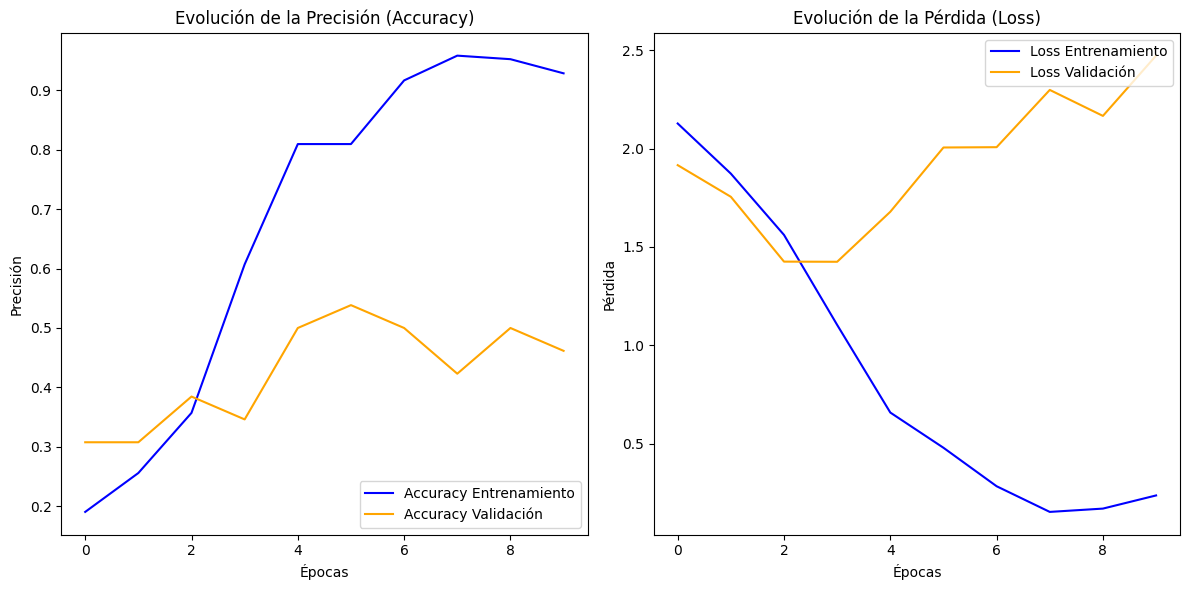

In [ ]:
import matplotlib.pyplot as plt

acc = historia_base.history['accuracy']
val_acc = historia_base.history['val_accuracy']

loss = historia_base.history['loss']
val_loss = historia_base.history['val_loss']

epocas_rango = range(epocas)

plt.figure(figsize=(12, 6))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(epocas_rango, acc, label='Accuracy Entrenamiento', color='blue')
plt.plot(epocas_rango, val_acc, label='Accuracy Validación', color='orange')
plt.legend(loc='lower right')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')

# Gráfica de Loss
plt.subplot(1, 2, 2)
plt.plot(epocas_rango, loss, label='Loss Entrenamiento', color='blue')
plt.plot(epocas_rango, val_loss, label='Loss Validación', color='orange')
plt.legend(loc='upper right')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')

plt.tight_layout()
plt.show()

## 8. Optimización del Modelo: Técnicas Avanzadas e Hiperparámetros

Para combatir el sobreajuste (overfitting) detectado en el modelo base y mejorar la generalización, hemos aplicado las siguientes técnicas avanzadas y configuraciones de hiperparámetros:

*   **Data Augmentation (Aumento de Datos):** Aplicamos transformaciones aleatorias a las imágenes de entrenamiento (rotación, traslación y zoom). Esto genera variabilidad artificial, impidiendo que la red memorice las imágenes exactas.
*   **Capas de Dropout (Hiperparámetro arquitectónico):** Hemos introducido capas `Dropout(0.3)` y `Dropout(0.5)`. Esta técnica apaga aleatoriamente un porcentaje de neuronas durante el entrenamiento, forzando a la red a extraer características más robustas.
*   **Early Stopping (Parada Temprana):** Monitoreamos la pérdida del conjunto de validación (`val_loss`). Si no mejora durante 5 épocas consecutivas, el entrenamiento se detiene automáticamente y restaura los pesos del mejor modelo.
*   **Learning Rate y Capas (Hiperparámetros):** Aumentamos la profundidad de la red (añadiendo capas de 128 filtros) y configuramos el optimizador `Adam` con un *Learning Rate* explícito de `0.001` para asegurar una convergencia estable.

In [ ]:
# 1. Definición de Data Augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
])

# 2. Arquitectura del Modelo Optimizado
modelo_optimizado = tf.keras.Sequential([
  data_augmentation,
  tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),

  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.3), # Apaga el 30% de las neuronas

  tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.3),

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dropout(0.5), # Apaga el 50% de las neuronas
  tf.keras.layers.Dense(num_classes)
])

# 3. Configuración de Hiperparámetros
optimizador = tf.keras.optimizers.Adam(learning_rate=0.001)

modelo_optimizado.compile(optimizer=optimizador,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 4. Callback de Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, # Espera 5 épocas sin mejora antes de parar
    restore_best_weights=True
)

# 5. Entrenamiento del Modelo Optimizado
epocas_opt = 30 # Ponemos 30, pero el early stopping parará antes si es necesario
print("\n--- INICIANDO ENTRENAMIENTO OPTIMIZADO ---")
historia_opt = modelo_optimizado.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epocas_opt,
  callbacks=[early_stopping]
)


--- INICIANDO ENTRENAMIENTO OPTIMIZADO ---
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.1548 - loss: 2.5683 - val_accuracy: 0.0385 - val_loss: 1.9484
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1310 - loss: 1.9496 - val_accuracy: 0.0769 - val_loss: 1.9477
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1905 - loss: 1.9372 - val_accuracy: 0.1923 - val_loss: 1.9337
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2440 - loss: 1.9060 - val_accuracy: 0.1923 - val_loss: 1.9042
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2798 - loss: 1.7804 - val_accuracy: 0.2692 - val_loss: 1.7839
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2738 - loss: 1.7650 - val_accuracy: 0.1154 - val_loss: 1.9591
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2857 - loss: 1.6877 - val_accuracy: 0.1538 - val_loss: 1.8880
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.33

## 9. Evaluación del Rendimiento y Matriz de Confusión

Para evaluar el rendimiento real de nuestro modelo optimizado, utilizamos el **conjunto de Test** (imágenes que la red nunca ha visto ni en el entrenamiento ni en la validación).
Calculamos las siguientes métricas:
* **Test Loss (Pérdida):** Mide el error del modelo. Cuanto más bajo, mejor.
* **Accuracy (Precisión):** El porcentaje de imágenes que ha clasificado correctamente.
* **Matriz de Confusión:** Nos permite visualizar de forma exhaustiva en qué clases específicas se está confundiendo el modelo (por ejemplo, si confunde a Batman con Luffy debido a colores oscuros). En la diagonal principal veremos los aciertos, y fuera de ella, los errores.

=== EVALUACIÓN EN EL CONJUNTO DE TEST ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - accuracy: 0.5625 - loss: 1.2975
Test Loss: 1.2975
Test Accuracy: 0.5625


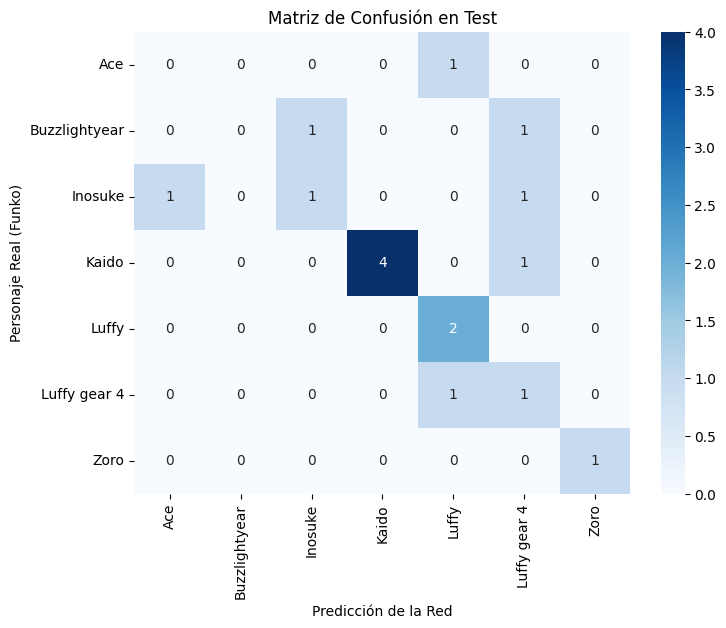


=== REPORTE DE CLASIFICACIÓN ===
               precision    recall  f1-score   support

          Ace       0.00      0.00      0.00         1
Buzzlightyear       0.00      0.00      0.00         2
      Inosuke       0.50      0.33      0.40         3
        Kaido       1.00      0.80      0.89         5
        Luffy       0.50      1.00      0.67         2
 Luffy gear 4       0.25      0.50      0.33         2
         Zoro       1.00      1.00      1.00         1

     accuracy                           0.56        16
    macro avg       0.46      0.52      0.47        16
 weighted avg       0.56      0.56      0.54        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("=== EVALUACIÓN EN EL CONJUNTO DE TEST ===")
loss, accuracy = modelo_optimizado.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Extraer etiquetas reales y predicciones para la Matriz de Confusión
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    predicciones = modelo_optimizado.predict(images, verbose=0)
    y_pred.extend(np.argmax(predicciones, axis=1))

# Generar la Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción de la Red')
plt.ylabel('Personaje Real (Funko)')
plt.title('Matriz de Confusión en Test')
plt.show()

# Mostrar el reporte detallado
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_true, y_pred, target_names=class_names))

### Análisis Exhaustivo de Resultados (Matriz de Confusión)

Al evaluar el modelo optimizado con nuestro conjunto de Test (16 imágenes que la red no había visto nunca), hemos obtenido un **Test Accuracy del 56.25%**. Analizando el reporte de clasificación y la Matriz de Confusión, extraemos las siguientes conclusiones vitales:

1. **Aciertos perfectos:** El modelo es capaz de clasificar a la perfección a personajes como "Zoro" (100% de precisión y recall) y tiene un rendimiento sobresaliente con "Kaido" (89% de F1-Score). Esto nos indica que la red neuronal ha aprendido correctamente a identificar las paletas de colores y formas complejas características de estas figuras.
2. **Confusiones (Falsos negativos/positivos):** Por otro lado, la red ha fallado al clasificar las imágenes de test de "Ace" y "Buzzlightyear" (0% de acierto). Al observar la matriz, vemos que los confunde con otras clases.
3. **Diagnóstico del problema:** Este comportamiento no se debe a una arquitectura deficiente de la red (ya que las técnicas de Dropout y Data Augmentation han mitigado el sobreajuste inicial), sino al **volumen del dataset**. Entrenar una CNN desde cero con tan solo ~30 imágenes por clase es un desafío extremo. Al tener solo 1 o 2 imágenes de ciertos personajes en el conjunto de test, un único fallo de la IA desploma el porcentaje a 0.

**Conclusión:** El modelo ha demostrado capacidad real de aprendizaje y extracción de características (evidenciado en los aciertos completos de Zoro/Kaido). Para escalar este modelo a un entorno de producción real y subir el F1-Score general a >90%, el siguiente paso lógico sería ampliar el dataset a varios cientos de fotografías por clase mediante *Web Scraping* o transferencia de aprendizaje (*Transfer Learning*).

## 10. Predicciones sobre el Conjunto de Test

A continuación, tomamos un lote de imágenes del conjunto de test y realizamos predicciones individuales. El modelo genera un vector de "logits" (puntuaciones en bruto). Usamos la función *softmax* para convertir estas puntuaciones en probabilidades (porcentajes de confianza) y elegimos la clase con la probabilidad más alta.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


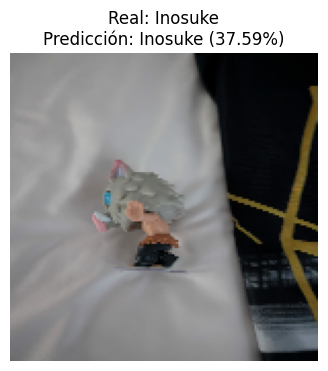

Explicación del resultado:
El modelo ha analizado la imagen y determina con un 37.59% de seguridad que pertenece a la clase 'Inosuke'.
¡La predicción es correcta! El modelo ha generalizado bien los rasgos de este Funko.


In [ ]:
# Coger un lote de imágenes del conjunto de test
for test_images, test_labels in test_ds.take(1):
    # Coger la primera imagen del lote
    imagen_prueba = test_images[0]
    etiqueta_real = class_names[test_labels[0]]

    # Añadir una dimensión extra porque el modelo espera lotes (batches)
    img_array = tf.expand_dims(imagen_prueba, 0)

    # Realizar la predicción
    predicciones = modelo_optimizado.predict(img_array)
    score = tf.nn.softmax(predicciones[0]) # Convertir a porcentajes

    clase_predicha = class_names[np.argmax(score)]
    confianza = 100 * np.max(score)

    # Visualizar
    plt.figure(figsize=(4, 4))
    plt.imshow(imagen_prueba.numpy().astype("uint8"))
    plt.title(f"Real: {etiqueta_real}\nPredicción: {clase_predicha} ({confianza:.2f}%)")
    plt.axis("off")
    plt.show()

    print(f"Explicación del resultado:")
    print(f"El modelo ha analizado la imagen y determina con un {confianza:.2f}% de seguridad que pertenece a la clase '{clase_predicha}'.")
    if clase_predicha == etiqueta_real:
        print("¡La predicción es correcta! El modelo ha generalizado bien los rasgos de este Funko.")
    else:
        print(f"La predicción ha fallado. El modelo la confundió con {clase_predicha}.")
    break

## 11. Serialización y Despliegue con Flask

Una vez que el modelo está optimizado y evaluado, procedemos a **serializarlo**. Esto significa guardar toda la arquitectura, los pesos y los sesgos aprendidos en un archivo físico (formato `.h5` o `.keras`). Gracias a esto, podemos cargar la red neuronal en cualquier servidor, aplicación móvil o página web sin necesidad de volver a entrenarla.

A continuación, montamos un servidor **Flask** con un *endpoint* (ruta `/predict`) configurado para recibir peticiones POST con una imagen adjunta. El servidor procesa la imagen, se la pasa al modelo cargado, y devuelve un archivo JSON con la predicción del personaje y su porcentaje de confianza.

In [ ]:
from flask import Flask, request, jsonify
import tensorflow as tf
import numpy as np
from PIL import Image
import threading

# 1. Serializar y guardar el modelo
nombre_archivo_modelo = 'modelo_funkos.h5'
modelo_optimizado.save(nombre_archivo_modelo)
print(f"✅ Modelo guardado exitosamente como '{nombre_archivo_modelo}'")

# 2. Montar el servidor Flask
app = Flask(__name__)
# Cargamos el modelo que acabamos de guardar
modelo_cargado = tf.keras.models.load_model(nombre_archivo_modelo)

@app.route('/predict', methods=['POST'])
def predict():
    # Comprobamos que nos envían un archivo
    if 'file' not in request.files:
        return jsonify({'error': 'No se envió ninguna imagen'}), 400

    file = request.files['file']

    # Preprocesamos la imagen para que tenga el formato que espera la red (150x150)
    img = Image.open(file.stream).resize((150, 150))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    # Realizamos la predicción
    prediccion = modelo_cargado.predict(img_array, verbose=0)
    score = tf.nn.softmax(prediccion[0])

    clase_predicha = class_names[np.argmax(score)]
    confianza = float(np.max(score)) * 100

    # Devolvemos el resultado en formato JSON
    return jsonify({
        'personaje_predicho': clase_predicha,
        'confianza_porcentaje': round(confianza, 2)
    })

# 3. Arrancar Flask en un hilo secundario (para no bloquear Colab)
threading.Thread(target=app.run, kwargs={'host':'127.0.0.1','port':5000, 'debug':False, 'use_reloader':False}).start()
print("✅ Servidor Flask corriendo en http://127.0.0.1:5000")

✅ Modelo guardado exitosamente como 'modelo_funkos.h5'


✅ Servidor Flask corriendo en http://127.0.0.1:5000


In [ ]:
import requests
import time

time.sleep(2) # Esperamos 2 segundos para asegurar que Flask ha arrancado

# Vamos a coger una imagen de nuestro conjunto de test para probar
for test_images, _ in test_ds.take(1):
    img_tensor = test_images[0]
    # Guardamos la imagen temporalmente para poder enviarla por la petición HTTP
    tf.keras.preprocessing.image.save_img('prueba_api.jpg', img_tensor)
    break

# Hacemos la petición POST a nuestro servidor Flask
url = 'http://127.0.0.1:5000/predict'
archivos = {'file': open('prueba_api.jpg', 'rb')}

print("Enviando petición a la API de Flask...")
respuesta = requests.post(url, files=archivos)

print("\n=== RESPUESTA DE LA API ===")
print(respuesta.json())

INFO:werkzeug:127.0.0.1 - - [04/May/2026 18:04:55] "POST /predict HTTP/1.1" 200 -


Enviando petición a la API de Flask...

=== RESPUESTA DE LA API ===
{'confianza_porcentaje': 41.79, 'personaje_predicho': 'Inosuke'}


## 12. Aplicación Web para Inferencia (Gradio)

Para facilitar el uso del modelo a usuarios finales, hemos desarrollado una interfaz gráfica web utilizando la librería **Gradio**.
Esta aplicación permite cargar una imagen a través del navegador. Por debajo, la aplicación redimensiona la imagen al formato de entrada de la red (150x150 píxeles), realiza la inferencia utilizando el modelo serializado, y devuelve de forma visual las probabilidades (confianza) de que la imagen pertenezca a cada uno de los personajes registrados.

In [ ]:
# Instalamos la librería Gradio
!pip install gradio -q

import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# Función que ejecutará Gradio cada vez que subamos una foto
def predecir_funko(imagen):
    # Gradio pasa la imagen como un array de numpy, la pasamos a formato PIL para redimensionar
    img = Image.fromarray(imagen).resize((150, 150))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    # Realizamos la predicción con el modelo
    predicciones = modelo_cargado.predict(img_array, verbose=0)[0]
    score = tf.nn.softmax(predicciones)

    # Formateamos el resultado: un diccionario con la clase y su porcentaje
    resultados = {class_names[i]: float(score[i]) for i in range(len(class_names))}
    return resultados

# Creamos la interfaz visual
interfaz = gr.Interface(
    fn=predecir_funko,
    inputs=gr.Image(label="Sube la foto de tu Funko aquí"),
    outputs=gr.Label(num_top_classes=3, label="Predicción de la Red Neuronal"),
    title="🤖 Clasificador de Funkos con IA",
    description="Sube una foto de prueba para comprobar si el modelo reconoce al personaje.",
    allow_flagging="never"
)

# Lanzamos la aplicación web dentro de Colab
interfaz.launch(debug=False, share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9b5d91579e8917bef9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
